# API request

### Connection check

In [1]:
import requests

BASE_URL = "https://gamma-api.polymarket.com"

r = requests.get(f"{BASE_URL}/events", params={"limit": 1})
print("Status code:", r.status_code)
print("Type:", type(r.json()))
print("Keys in first event:", r.json()[0].keys())


Status code: 200
Type: <class 'list'>
Keys in first event: dict_keys(['id', 'ticker', 'slug', 'title', 'description', 'resolutionSource', 'startDate', 'creationDate', 'endDate', 'image', 'icon', 'active', 'closed', 'archived', 'new', 'featured', 'restricted', 'liquidity', 'volume', 'openInterest', 'sortBy', 'category', 'published_at', 'createdAt', 'updatedAt', 'competitive', 'volume24hr', 'volume1wk', 'volume1mo', 'volume1yr', 'liquidityAmm', 'liquidityClob', 'commentCount', 'markets', 'series', 'tags', 'cyom', 'closedTime', 'showAllOutcomes', 'showMarketImages', 'enableNegRisk', 'seriesSlug', 'negRiskAugmented', 'pendingDeployment', 'deploying', 'requiresTranslation'])


### List of tags

In [1]:
import requests

url = "https://gamma-api.polymarket.com/tags"
limit = 500
offset = 0
unique_tags = {}  # key = id, value = label

while True:
    params = {"limit": limit, "offset": offset}
    response = requests.get(url, params=params)
    response.raise_for_status()

    batch = response.json()
    if not batch:
        break

    for tag in batch:
        unique_tags[tag["id"]] = tag["label"]

    offset += limit
    print(f"Tags collected: {len(unique_tags)} | current offset: {offset}")  # ← progress

# Convert to a list of dicts
tag_list = [{"id": id_, "label": label} for id_, label in unique_tags.items()]

print(f"\nTotal unique tags: {len(tag_list)}")
print(f"First 10 tags (sample):")
for t in tag_list[:10]:
    print(t)

if len(tag_list) > 10:
    print(f"... and {len(tag_list) - 10} more tags")

Tags collected: 300 | current offset: 500
Tags collected: 600 | current offset: 1000
Tags collected: 900 | current offset: 1500
Tags collected: 1200 | current offset: 2000
Tags collected: 1500 | current offset: 2500
Tags collected: 1800 | current offset: 3000
Tags collected: 2100 | current offset: 3500
Tags collected: 2400 | current offset: 4000
Tags collected: 2700 | current offset: 4500
Tags collected: 3000 | current offset: 5000
Tags collected: 3300 | current offset: 5500
Tags collected: 3328 | current offset: 6000

Total unique tags: 3328
First 10 tags (sample):
{'id': '101259', 'label': 'Health and Human Services'}
{'id': '101842', 'label': 'Sweeden'}
{'id': '101302', 'label': 'attorney general'}
{'id': '102067', 'label': 'Madrid Open'}
{'id': '101944', 'label': 'Crypto Summit'}
{'id': '100826', 'label': 'DET'}
{'id': '100539', 'label': 'Costello'}
{'id': '102981', 'label': 'Testing tag'}
{'id': '101528', 'label': 'altcoin'}
{'id': '102846', 'label': 'Best of 2025'}
... and 3318 m

In [3]:
# Keywords for political tags
political_keywords = ["Politics", "government", "election", "policy", "regime", "democracy", "law", "party"]

# Filter tags by keywords (case-insensitive)
political_tags = [
    tag for tag in tag_list
    if any(kw.lower() in tag["label"].lower() for kw in political_keywords)
]

print(f"Total political tags: {len(political_tags)}")
for t in political_tags:
    print(t)

Total political tags: 86
{'id': '99', 'label': 'u.s. 2024 elections'}
{'id': '877', 'label': 'NY Special Election'}
{'id': '1122', 'label': 'women in politics'}
{'id': '400', 'label': 'election 2024'}
{'id': '101616', 'label': 'Speaker Election'}
{'id': '102776', 'label': 'Dutch Election'}
{'id': '858', 'label': 'government shutdown'}
{'id': '102312', 'label': 'General election'}
{'id': '789', 'label': 'US Politics'}
{'id': '103728', 'label': 'people power party'}
{'id': '104112', 'label': 'Kurdistan Regional Government'}
{'id': '103997', 'label': 'democracy'}
{'id': '103729', 'label': "People's Power Party"}
{'id': '103788', 'label': 'by election'}
{'id': '103726', 'label': 'Democratic Party of Korea'}
{'id': '573', 'label': 'american politics'}
{'id': '188', 'label': 'U.S. Politics'}
{'id': '1458', 'label': 'player selection'}
{'id': '103793', 'label': 'Nepal Election'}
{'id': '101972', 'label': 'specil election'}
{'id': '274', 'label': 'presidential election 2024'}
{'id': '102786', 

### Political events. Active markets

In [4]:
import requests
import pandas as pd

BASE_URL = "https://gamma-api.polymarket.com/events"
LIMIT = 500
all_political_events = []
offset = 0

print("Starting download of open political events from Polymarket")

while True:
    params = {
        "limit": LIMIT,
        "offset": offset,
        "active": True,
        "closed": False,
    }
    response = requests.get(BASE_URL, params=params)
    response.raise_for_status()
    data = response.json()

    if not data:
        break

    # Filter by Politics tag
    political_events_batch = [
        event
        for event in data
        if any(tag.get("slug") == "politics" for tag in event.get("tags", []))
    ]

    all_political_events.extend(political_events_batch)

    print(f"offset={offset}")

    if len(data) < LIMIT:
        break

    offset += LIMIT

print("Download complete")

df = pd.DataFrame(all_political_events)
df.to_csv("events_open_politics.csv", index=False)

Starting download of open political events from Polymarket
offset=0
offset=500
offset=1000
offset=1500
offset=2000
offset=2500
offset=3000
offset=3500
offset=4000
offset=4500
offset=5000
offset=5500
offset=6000
offset=6500
offset=7000
offset=7500
offset=8000
offset=8500
Download complete


# Matching with countries

Country matching was performed using a rule-based NLP approach (dictionary method).
A predefined dictionary of country names and their variations was matched
against event titles and descriptions. Each event was classified into two categories:


**actor country** – the country initiating or driving the event, and

**subject country** – the country affected by or targeted in the event.

In [5]:
import pandas as pd
import ast

### Dictionary

In [6]:
ACTOR_TO_COUNTRY = {
    # USA
    "trump": "USA", "biden": "USA", "harris": "USA", "congress": "USA",
    "u.s. politics": "USA", "us politics": "USA", "jerome powell": "USA",
    "fed": "USA", "senate": "USA", "house": "USA", "scotus": "USA",
    "elon musk": "USA", "rfk": "USA", "doge": "USA",
    "us election": "USA", "midterms": "USA", "primaries": "USA",
    "primary elections": "USA", "house elections": "USA",
    "house primary": "USA", "senate primary": "USA",
    "democratic primary": "USA", "republican primary": "USA",
    "governor primary": "USA", "trump presidency": "USA",
    "epstein": "USA", "bernie sanders": "USA", "bernie": "USA",
    "obama": "USA", "schumer": "USA", "alito": "USA",
    "mangione": "USA", "luigi mangione": "USA", "tsa": "USA",
    "andrew tate": "USA",
    # Russia
    "putin": "Russia", "kremlin": "Russia",
    # Ukraine
    "zelensky": "Ukraine",
    # Iran
    "khamenei": "Iran",
    # Israel
    "netanyahu": "Israel",
    # China
    "xi": "China",
    # UK
    "starmer": "UK", "keir": "UK", "sunak": "UK",
    # France
    "macron": "France",
    # Germany
    "scholz": "Germany", "merz": "Germany",
    # India
    "modi": "India",
    # South Korea
    "yoon": "South Korea",
    # Venezuela
    "maduro": "Venezuela",
    # Turkey
    "erdogan": "Turkey",
    # Hungary
    "orban": "Hungary",
    # Syria
    "al-sharaa": "Syria",
    # Canada
    "trudeau": "Canada", "carney": "Canada",
    # Mexico
    "sheinbaum": "Mexico",
    # Brazil
    "lula": "Brazil",
    # Argentina
    "milei": "Argentina",
    # Japan
    "kishida": "Japan", "ishiba": "Japan",
    # North Korea
    "kim jфong": "North Korea",
    # Saudi Arabia
    "mbs": "Saudi Arabia",
}

# Direct country / place tags  (used for SUBJECT logic)
COUNTRY_TAGS = {
    "ukraine": "Ukraine", "russia": "Russia", "israel": "Israel",
    "iran": "Iran", "china": "China", "venezuela": "Venezuela",
    "france": "France", "uk": "UK", "germany": "Germany",
    "india": "India", "south korea": "South Korea", "hungary": "Hungary",
    "greenland": "Greenland", "gaza": "Palestine", "syria": "Syria",
    "turkey": "Turkey", "canada": "Canada", "mexico": "Mexico",
    "brazil": "Brazil", "argentina": "Argentina", "japan": "Japan",
    "north korea": "North Korea", "saudi": "Saudi Arabia",
    # USA direct tags
    "usa": "USA", "u.s.": "USA", "united states": "USA",
    "nyc": "USA", "new york city": "USA", "texas": "USA",
    "california": "USA", "minnesota unrest": "USA",
}

# Tags that mean "International" (no single country)
INTERNATIONAL_TAGS = {
    "nato", "eu", "un", "g7", "g20", "world", "geopolitics",
    "global elections", "world elections", "international",
    "middle east", "foreign policy", "ukraine peace deal",
    "trump-putin", "trump-zelenskyy", "security guarantee",
    "eurovision", "music",
}

# Generic tags to skip
SKIP_TAGS = {
    "politics", "elections", "2025 predictions", "culture", "economy",
    "courts", "immigration", "immigration/border", "resign", "creators",
    "all-in", "monthly", "nov 4 elections", "fed rates", "ukraine map",
    "grooming gangs", "ai", "tech", "big tech", "openai", "science",
    "crypto", "finance", "bitcoin", "inflation", "macro indicators",
    "taxes", "prediction markets", "tweet markets", "celebrities",
    "all", "warner bros", "tiktok", "abortion", "referendum",
}

### Core functions

In [7]:
def extract_tag_labels(tags_str):
    """Parse tags field → list of lowercase label strings."""
    if pd.isna(tags_str):
        return []
    try:
        tags = ast.literal_eval(tags_str)
        return [t.get("label", "").strip().lower() for t in tags if t.get("label")]
    except Exception:
        return []

In [8]:
def assign_actor_country(title, tags_str):
    """
    Priority:
      1. Leader/institution tag → their country
      2. Direct country tag
      3. International tag → 'International'
      4. Fallback: search title
    """
    labels = extract_tag_labels(tags_str)

    for label in labels:
        if label in SKIP_TAGS:
            continue
        if label in ACTOR_TO_COUNTRY:
            return ACTOR_TO_COUNTRY[label]

    for label in labels:
        if label in COUNTRY_TAGS:
            return COUNTRY_TAGS[label]

    for label in labels:
        if label in INTERNATIONAL_TAGS:
            return "International"

    # Fallback: title search
    title_lower = (title or "").lower()
    for actor, country in ACTOR_TO_COUNTRY.items():
        if actor in title_lower:
            return country
    for tag, country in COUNTRY_TAGS.items():
        if tag in title_lower:
            return country

    return None

In [9]:
def assign_subject_country(title, tags_str):
    """
    Priority:
      1. Direct country tag (место/страна события)
      2. Leader tag → their country (если страна = страна лидера)
      3. International tag → 'International'
      4. Fallback: search title
    """
    labels = extract_tag_labels(tags_str)

    for label in labels:
        if label in SKIP_TAGS:
            continue
        if label in COUNTRY_TAGS:
            return COUNTRY_TAGS[label]

    for label in labels:
        if label in SKIP_TAGS:
            continue
        if label in ACTOR_TO_COUNTRY:
            return ACTOR_TO_COUNTRY[label]

    for label in labels:
        if label in INTERNATIONAL_TAGS:
            return "International"

    # Fallback: title search
    title_lower = (title or "").lower()
    for tag, country in COUNTRY_TAGS.items():
        if tag in title_lower:
            return country
    for actor, country in ACTOR_TO_COUNTRY.items():
        if actor in title_lower:
            return country

    return None

### Run on data

In [10]:
if __name__ == "__main__":
    input_file = "events_open_politics.csv"
    output_file = "events_with_country.csv"

    df = pd.read_csv(input_file)

    df["country_actor"] = df.apply(
        lambda row: assign_actor_country(row["title"], row["tags"]), axis=1
    )
    df["country_subject"] = df.apply(
        lambda row: assign_subject_country(row["title"], row["tags"]), axis=1
    )
    
    df.to_csv(output_file, index=False)
    print(f"\nSaved to {output_file}")


Saved to events_with_country.csv


*The resulting country assignments were then manually reviewed and verified to ensure accuracy of matching.*

**Diagnostic**

In [11]:
import pandas as pd

df = pd.read_csv("events_with_country_28-02.csv")

print(f"Total events: {len(df)}")
print(f"Unique actor countries: {df['country_actor'].nunique()}")
print(f"Unique subject countries: {df['country_subject'].nunique()}")
print(f"Events where actor ≠ subject: {(df['country_actor'] != df['country_subject']).sum()}")

Total events: 1486
Unique actor countries: 64
Unique subject countries: 71
Events where actor ≠ subject: 232


### V-Dem Index

In [12]:
import pandas as pd

# Load data
df = pd.read_csv("events_with_country_28-02.csv")

# Load only needed columns from V-Dem
vdem = pd.read_csv("V-Dem-CY-Core-v15.csv", usecols=['country_name', 'year', 'v2x_polyarchy', 'v2x_libdem'])

# Latest year per country
vdem_latest = vdem.loc[vdem.groupby('country_name')['year'].idxmax()][['country_name', 'v2x_polyarchy', 'v2x_libdem']]

# Name mapping for mismatched countries
name_map = {
    'USA': 'United States of America',
    'UK': 'United Kingdom',
    'Turkey': 'Türkiye',
    'Palestine': 'Palestine/West Bank',
    'Greenland': 'Denmark',
}

df['actor_mapped'] = df['country_actor'].map(name_map).fillna(df['country_actor'])
df['subject_mapped'] = df['country_subject'].map(name_map).fillna(df['country_subject'])

# Merge for actor
df = df.merge(
    vdem_latest.rename(columns={
        'country_name': 'actor_mapped',
        'v2x_polyarchy': 'actor_polyarchy',
        'v2x_libdem': 'actor_libdem'
    }),
    on='actor_mapped', how='left'
)

# Merge for subject
df = df.merge(
    vdem_latest.rename(columns={
        'country_name': 'subject_mapped',
        'v2x_polyarchy': 'subject_polyarchy',
        'v2x_libdem': 'subject_libdem'
    }),
    on='subject_mapped', how='left'
)

# Drop helper columns
df.drop(columns=['actor_mapped', 'subject_mapped'], inplace=True)

print(f"Total rows: {len(df)}")
print(f"Actor polyarchy NaN: {df['actor_polyarchy'].isna().sum()}")
print(f"Subject polyarchy NaN: {df['subject_polyarchy'].isna().sum()}")

print("\nActor NaN countries:")
print(df[df['actor_polyarchy'].isna()]['country_actor'].value_counts())

print("\nSubject NaN countries:")
print(df[df['subject_polyarchy'].isna()]['country_subject'].value_counts())

Total rows: 1486
Actor polyarchy NaN: 38
Subject polyarchy NaN: 56

Actor NaN countries:
International    37
Name: country_actor, dtype: int64

Subject NaN countries:
International    55
Name: country_subject, dtype: int64


# Market Uncertainty

Each event contains one or more markets, where outcome prices reflect the probability distribution (e.g. 50/50, 80/20, etc.). Since events may contain multiple markets, we first check the distribution of market counts per event.

### Checking events with multiple or zero markets

In [13]:
markets_count = df['markets'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0)
print(markets_count.value_counts().sort_index())

0     329
1     402
2      66
3      46
4      22
5      27
6      22
7      34
8     441
9      10
10     10
11      3
12      1
13     70
14      2
15      1
Name: markets, dtype: int64


**Looking at the event with 8 markets**

In [14]:
example = df[markets_count == 8].iloc[0]
markets = ast.literal_eval(example['markets'])
for m in markets:
    print(m.get('question'), '|', m.get('volume'))

Will Russia capture Lyman by December 31? | 764798.497059
Will Russia capture Lyman by November 30? | 142123.928318
Will Russia capture Lyman by March 31, 2026? | 523378.095306
Will Russia capture Lyman by January 31, 2026? | 72028.870016
Will Russia capture Lyman by February 28, 2026? | 84721.197367
Will Russia capture Lyman by June 30, 2026? | 4164.063366
Will Russia capture Lyman by April 30, 2026? | 26877.820712
Will Russia capture Lyman by December 31, 2026? | 5627.524129


**Looking at the event with 0 markets**

In [15]:
empty_markets = df[markets_count == 0]
print(empty_markets[['title', 'description']].head(20))

                                                 title  \
15           Will Russia capture Kostyantynivka by...?   
20                Democratic Presidential Nominee 2028   
22                   Presidential Election Winner 2028   
24                Republican Presidential Nominee 2028   
25              Texas Republican Senate Primary Winner   
30     Which party wins 2028 US Presidential Election?   
41                     Colombia Senate Election Winner   
42   Colombia Chamber of Representatives Election W...   
43    Colombia Presidential Election 1st round winner?   
44                      Colombia Presidential Election   
47               Who will Trump nominate as Fed Chair?   
59           Michigan Democratic Senate Primary Winner   
60              Maine Democratic Senate Primary Winner   
61     South Carolina Republican Senate Primary Winner   
62                        Brazil Presidential Election   
65               Where will Trump and Putin meet next?   
70            

As we can see, events with multiple markets typically contain the same questionsplit across overlapping time periods (e.g. "Will Russia capture Lyman by [date]?"). Therefore, rather than averaging across these correlated markets, we select the one with ***the highest trading volume*** as the most representative and liquid signal of uncertainty.

### Extracting outcome prices from markets

In [16]:
import ast

def extract_prices_max_volume(markets_str):
    """Extract outcome prices from the market with the highest trading volume"""
    try:
        markets = ast.literal_eval(markets_str)
        if not markets:
            return None
        best = max(markets, key=lambda m: float(m.get('volume', 0) or 0))
        prices_str = best.get('outcomePrices', '[]')
        prices = ast.literal_eval(prices_str)
        return [float(p) for p in prices]
    except:
        return None

df['outcome_prices'] = df['markets'].apply(extract_prices_max_volume)

### Shannon Entropy

Shannon entropy measures uncertainty in a binary market. It reaches its maximum value (ln(2) ≈ 0.693) when outcome prices are equal (50/50), indicating maximum uncertainty, and approaches zero when one outcome dominates (e.g. 99/1).

Formula: H = −p·ln(p) − (1−p)·ln(1−p)

In [17]:
import numpy as np

def binary_entropy(prices):
    """Shannon entropy for a binary market. Max = 0.693 at 50/50, min = 0 at 100/0"""
    if prices is None or len(prices) < 2:
        return None
    p = np.clip(prices[0], 1e-10, 1 - 1e-10)
    return -p * np.log(p) - (1 - p) * np.log(1 - p)

df['entropy'] = df['outcome_prices'].apply(binary_entropy)

print(f"Missing: {df['entropy'].isna().sum()}")
print(f"Mean: {df['entropy'].mean():.3f}")
print(f"Max: {df['entropy'].max():.3f}")

Missing: 332
Mean: 0.345
Max: 0.693


### Proximity to 50/50

A simpler alternative measure of uncertainty — the closer the leading outcome price is to 0.5, the higher the uncertainty. The metric ranges from 0 (complete certainty, price at 0 or 1) to 0.5 (maximum uncertainty, price at 0.5).

Formula: Proximity = 0.5 − |p − 0.5|

In [18]:
def proximity_5050(prices):
    """Proximity to 50/50. Max = 0.5 at 50/50, min = 0 at 100/0"""
    if prices is None or len(prices) < 2:
        return None
    return 0.5 - abs(prices[0] - 0.5)

df['proximity_5050'] = df['outcome_prices'].apply(proximity_5050)

print(f"Missing: {df['proximity_5050'].isna().sum()}")
print(f"Mean: {df['proximity_5050'].mean():.3f}")
print(f"Max: {df['proximity_5050'].max():.3f}")

Missing: 332
Mean: 0.142
Max: 0.500


# Market age calculation

This variable measures how many days each event has been active at the time of data collection (February 28, 2026). Older markets tend to accumulate more volume, so this serves as a control variable.

In [19]:
df['createdAt'] = pd.to_datetime(df['createdAt']).dt.tz_localize(None)
df['market_age_days'] = (pd.Timestamp('2026-02-28') - df['createdAt']).dt.days + 1

print(f"Mean age: {df['market_age_days'].mean():.0f} days")
print(f"Min: {df['market_age_days'].min()}, Max: {df['market_age_days'].max()}")

Mean age: 65 days
Min: 0, Max: 421


# Classification of events

We classify events using a dictionary-based method (Grimmer & Stewart, 2013) as the primary approach, validated by Latent Dirichlet Allocation (Blei et al., 2003) as an unsupervised cross-check on event titles. Agreement is measured using the Adjusted Rand Index and Normalized Mutual Information.

## Rule-based NLP

Drawing on CAMEO (Schrodt, 2012) and the information demand framework (Wlezien & Soroka, 2010), we define five categories: 
- Elections
- International Conflicts
- Domestic Policy
- Leadership Changes
- Other

For four categories, we map each of Polymarket's 511 unique tags to exactly one category via dictionaries, using exact set matching with priority logic for ambiguous cases. For Leadership Changes, Polymarket lacks dedicated tags, so we use title-based pattern matching on structured phrases ("out by", "impeach", "regime fall"), with exclusion rules to filter false positives.

### Extracting tags

In [20]:
def extract_tag_labels(tags_str):
    if pd.isna(tags_str):
        return []
    try:
        tags = ast.literal_eval(tags_str)
        return [t['label'] for t in tags if isinstance(t, dict) and 'label' in t]
    except:
        return []

df['tag_labels'] = df['tags'].apply(extract_tag_labels)

### Dictionary

In [21]:
ELECTIONS = {
    "Elections", "Midterms", "Nov 4 Elections", "House Elections",
    "Primaries", "primary elections", "US Election", "Global Elections",
    "Democratic Primary", "Republican Primary", "House Primary",
    "World Elections", "Governor Primary", "Senate Primary",
    "Texas Senate", "Texas Primary", "Michigan Primary", "Illinois Primary",
    "Iowa Primary", "Florida Primary", "Minnesota Primary", "Colorado Primary",
    "New Hampshire Primary", "Maine Primary", "South Carolina Primary",
    "Georgia Primary", "Alabama Primary", "Nebraska Primary",
    "Rhode Island Primary", "Kentucky Primary", "North Carolina Primary",
    "Ohio Primary", "Mississippi Primary", "New York Primary",
    "Massachusetts Primary", "Virginia Primary", "Arizona Primary",
    "Kansas Primary", "Oregon Primary", "Oklahoma Primary",
    "Pennsylvania Primary", "Arkansas Primary", "West Virginia Primary",
    "Idaho Primary", "New Mexico Primary", "Connecticut Primary",
    "South Dakota Primary", "Tennessee Primary", "Vermont Primary",
    "Wisconsin Primary", "Delaware Primary", "Louisiana Primary",
    "Maryland Primary", "Wyoming Primary", "Missouri Primary",
    "Utah Primary", "Montana Primary", "Nevada Primary",
    "California Primary", "New Jersey Primary",
    "Honduras Election", "Thailand Election", "Bolivia Election",
    "Bangladesh Election", "Nepal Election", "Chile Election",
    "Portugal Election", "Canadian Election",
    "Popular Vote", "Mayoral Elections", "NYC Mayor", "by election",
    "Farrer", "Macro Election 2", "referendum", "Referenda",
    "voter fraud", "voter ID", "votes", "midterm", "first round",
    "nominate",
    "castille and leon", "Baden-Württemberg", "rhineland-palatinate",
    "Saxony-Anhalt", "Mecklenburg-Vorpommern",
    "Gemeenteraad", "Gemeenteraad van Amsterdam", "Gemeenteraad Den Haag",
    "municipal council", "city council", "gerrymander", "district",
    "Romania",
}

INTL_CONFLICTS = {
    "Geopolitics", "World", "Foreign Policy", "Macro Geopolitics",
    "world affairs",
    "Ukraine", "Ukraine Map", "Ukraine Peace Deal",
    "Middle East", "Gaza", "Lebanon", "Syria", "Yemen", "iraq",
    "Sudan", "Sudan Map", "Afghanistan", "kabul",
    "Israel", "Iran", "China", "India", "russia", "north korea",
    "taiwan", "Taiwan", "Turkey", "pakistan", "somalia", "Somalia",
    "Somalian", "Somali", "Hungary",
    "putin", "zelensky", "zelenskyy", "Xi", "xi jinping",
    "Khamenei", "Ali Khamenei", "supreme leader",
    "netanyahu", "Orban", "Ramzan Kadyrov",
    "Military Actions", "nato", "Russia Capture", "Daily Strikes",
    "nuclear", "nuke", "shoot down", "shoots down", "Tomahawk",
    "defense", "military", "AFRICOM", "North Atlantic Treaty",
    "Hezbollah", "hamas", "houthis", "houthi", "ISIS",
    "Trump-Putin", "Trump-Xi", "Trump-Netanyahu",
    "Trump-Zelenskyy", "Trump-Zelensky", "Trump x al-Sharaa",
    "US-Iran", "India-Pakistan", "Thailand-Cambodia",
    "Abraham Accords", "Security Guarantee",
    "Greenland", "Denmark", "Hong Kong", "Kupyansk", "donestk",
    "annex", "ship", "oil ship",
    "Witkoff", "Kushner", "Lid", "Mette Frederiksen",
    "United Nations", "Hide From China",
    "Vietnam", "Chechnya", "palestine", "Thailand", "Asia", "Global",
}

DOMESTIC_POLICY = {
    "Trump", "Trump Presidency", "Trump-Machado",
    "U.S. Politics", "US Politics",
    "Biden", "Kamala", "Vance", "Elon Musk",
    "Alexandria Ocasio-Cortez", "aoc", "Gretchen Whitmer",
    "Ro Khanna", "Khanna", "MTG", "marjorie taylor greene",
    "Crockett", "Cornyn", "Talarico", "Paxton",
    "Mamdani", "Zohran Mamdani", "Trump x Mamdani",
    "bernie sanders", "melania", "Hillary",
    "madison sheahan", "Catherine Connoly",
    "Nick Shirley", "tucker carlson", "massie", "MAGA",
    "democrat", "democrats", "democratic party",
    "republican", "republicans", "republican party",
    "Tariffs", "Trade War", "Economy", "Economic Policy",
    "Fed", "Fed Rates", "Jerome Powell", "federal reserve", "Warsh",
    "Inflation", "Macro Indicators", "oil",
    "ECB", "Global Rates", "European Central Bank",
    "Immigration", "Immigration/Border", "ICE", "TSA",
    "DHS", "Homeland Security", "Department of Homeland Security",
    "Border Patrol", "USBP", "immigrants", "IEEPA",
    "Taxes", "Gov Shutdown", "Shut Down", "funding bill",
    "Congress", "Senate", "house of representatives", "house",
    "Cannabis", "Marijuana", "H-1B", "abortion", "us government",
    "SOTU", "State of Union", "state of the union",
    "Courts", "SCOTUS", "Supreme Court ",
    "indict", "lawsuit", "criminal", "contempt", "hearing",
    "fraud", "legal", "doj", "ftc", "sue", "us law",
    "humphreys", "Humphrey's Executor", "Alito",
    "Epstein", "Jeffrey Epstein", "Jeffrey", "Maxwell",
    "Ghislaine Maxwell", "clinton", "bill clinton",
    "ftx", "Sam Bankman-Fried",
    "Prince Andrew", "Andrew Mountbatten-Windsor",
    "Jonathan Ross", "andrew tate",
    "Mug shot", "files", "epstein files", "Grooming Gangs",
    "Eric Adams", "mangione", "Luigi Mangione",
    "resign", "oust", "Macron", "Starmer", "keir", "arrest",
    "Cabinet", "Noem", "kristi noem", "Kash Patel",
    "pam bondi", "Tulsi Gabbard", "rubio", "marco rubio",
    "nomination", "Approval", "approvals", "approval rating",
    "detain", "federalize", "purge", "Davos",
    "South Korea", "Democratic Party of Korea",
    "People's Power Party", "people power party",
    "Venezuela", "maduro", "Nicolas Maduro",
    "Maria Machado", "Maria Corina Machado",
    "Bolivia", "Brazil", "STF",
    "Mexico Cartel War", "mencho", "El Mencho",
    "Jalisco Cartel", "cartel", "mexico",
    "argentina", "milei", "Colombia", "Cuba",
    "indonesia", "Japan", "Australia",
    "uk", "France", "Germany", "Europe", "eu", "European Union ",
    "Marine Le Pen", "Netherlands", "dutch", "holland",
    "spain", "PP", "Alex", "Pretti", "ventura", "seguro",
    "italy", "greece", "ireland", "Irish", "England", "Britain", "PM",
    "latvia", "switzerland", "Poland",
    "Minnesota Unrest", "Minneapolis", "minnesota",
    "Ilhan Omar", "Tim Walz", "steve grove",
    "New York City", "New York", "Florida", "Los Angeles", "LA",
    "California", "DC", "Illinois", "texas", "virginia",
    "north carolina", "michigan", "MN", "FL",
    "White House", "President", "presidential",
    "protest", "general", "meet",
    "Fact Check", "news", "News Story", "News Stories",
    "Tweet Markets", "Mentions", "picture", "Apology",
    "flip off", "middle finger", "kippah", "yamaka",
    "mail", "Machine", "search", "box", "bingo", "pmq",
    "Canada", "New York Times", "bangladesh", "Nigeria",
    "mayor", "nyc", "alien", "armenia", "Twitter",
    "Greta Thunberg", "change", "switch", "parties", "El paso",
}

OTHER = {
    "Culture", "Tech", "Crypto", "Bitcoin", "Ethereum", "AI",
    "artificial intelligence", "OpenAI", "xAI",
    "Musk v. Altman", "Musk v Altman",
    "Big Tech", "microsoft", "cloudflare", "TikTok",
    "GTA VI", "Sports", "football", "NFL", "redskins",
    "Science", "Climate & Science", "Awards", "Grammys", "Music",
    "Celebrities", "obama",
    "Industry", "Business", "Finance", "Derivatives",
    "Parent For Derivative", "Prediction Markets",
    "TMTG", "TAE", "merger", "Acquisitions", "acquire", "join",
    "currency", "economics",
    "Earn 4%", "Parlays", "Creators", "All-In", "All", "Other",
    "Jason Calacanis", "mov",
    "Rewards 200, 3.5, 50", "Rewards 50, 4.5, 100",
    "Rewards 20, 4.5, 50", "rewards 10, 4.5, 50",
    "2025 Predictions", "2026 Predictions", "Hide From New",
    "hack", "outage", "airport", "strike", "flight", "bus",
    "skiing", "puerto Vallarta", "jalisco", "aliens", "ufo", "uap",
    "2026 Winter Games", "day care", "Warner Bros",
    "ron desantis", "America Party", "Pierre", "Communist", "APR",
}

### Run on data

In [22]:
def classify_event(tag_labels, title):
    """
    Dictionary-based event classification (Grimmer & Stewart, 2013).
    
    Uses exact tag matching for 4 categories + title patterns for 
    Leadership Changes (where Polymarket lacks dedicated tags).
    
    Priority: Leadership Changes > Elections > Intl Conflicts > Domestic Policy > Other
    
    Leadership Changes gets highest priority because these events 
    often carry tags from other categories (e.g. "Geopolitics", "France")
    but the core question is about a leader staying/going.
    """
    # ── Step 1: Check Leadership Changes via title ──
    t = title.lower()
    
    is_leadership = False
    # Exclusions first (elections disguised as leadership)
    exclude = any(exc in t for exc in [
        'win outright', 'what will', 'say at', 'primary'
    ])
    if not exclude:
        is_leadership = any(p in t for p in [
            ' out by', ' out as ', ' out in ', ' out of office',
            ' out before', ' out over',
            'resign', 'impeach', 'oust',
            'regime fall', 'regime change', 'coup attempt',
            'out of custody', 'fired/resigns',
            'next prime minister', 'next president',
        ])
    
    if is_leadership:
        return "Leadership Changes"
    
    # ── Step 2: Tag-based classification for the rest ──
    tag_set = set(tag_labels)
    
    n_elec = len(tag_set & ELECTIONS)
    n_intl = len(tag_set & INTL_CONFLICTS)
    n_dome = len(tag_set & DOMESTIC_POLICY)
    n_othe = len(tag_set & OTHER)
    
    specific_elec = tag_set & (ELECTIONS - {"Elections"})
    
    if len(specific_elec) >= 1 and n_elec > n_intl:
        return "Elections"
    if n_intl >= 2 or (n_intl >= 1 and n_elec == 0 and n_dome == 0):
        return "Intl Conflicts"
    if n_elec >= 1:
        return "Elections"
    if n_dome >= 1:
        return "Domestic Policy"
    if n_othe >= 1:
        return "Other"
    return "Other"

# Apply
df['event_type'] = df.apply(
    lambda row: classify_event(row['tag_labels'], row.get('title', '')), 
    axis=1
)

# Results
print("Classification results:")
print("=" * 50)
for cat, n in df['event_type'].value_counts().items():
    print(f"  {cat:25s} {n:5d} ({100*n/len(df):.1f}%)")

# Check unmapped tags
all_mapped = (ELECTIONS | INTL_CONFLICTS | DOMESTIC_POLICY 
              | OTHER | {"Politics"})
all_in_data = set(t for labels in df['tag_labels'] for t in labels)
unmapped = all_in_data - all_mapped
print(f"\nUnmapped tags: {len(unmapped)}")

Classification results:
  Elections                   845 (56.9%)
  Intl Conflicts              290 (19.5%)
  Domestic Policy             240 (16.2%)
  Leadership Changes           91 (6.1%)
  Other                        20 (1.3%)

Unmapped tags: 0


In [25]:
df.to_csv('polymarket_data_not_checked.csv', index=False)
print(f"Saved: polymarket_data_not_checked.csv ({df.shape[0]} rows, {df.shape[1]} columns)")

Saved: polymarket_data_not_checked.csv (1486 rows, 74 columns)


*The resulting country assignments were then manually reviewed and verified to ensure accuracy of matching.*

In [26]:
df = pd.read_csv("polymarket_data.csv")

## LDA

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [29]:
# Preprocessing → Document-Term Matrix (CountVectorizer, not TF-IDF — LDA expects counts)
titles = df['title'].fillna('').str.lower()

count_vec = CountVectorizer(
    max_features=500,
    stop_words='english',
    min_df=3,
    max_df=0.7,
    ngram_range=(1, 2),
)
dtm = count_vec.fit_transform(titles)

try:
    feature_names = count_vec.get_feature_names_out()
except AttributeError:
    feature_names = count_vec.get_feature_names()

print(f"Document-Term Matrix: {dtm.shape[0]} documents × {dtm.shape[1]} terms")

Document-Term Matrix: 1486 documents × 500 terms


In [30]:
# LDA with 5 topics
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    max_iter=50,
    learning_method='batch',
)
doc_topics = lda.fit_transform(dtm)
df['lda_topic'] = doc_topics.argmax(axis=1)

print("LDA Topics (top 10 terms each):")
print("=" * 60)
for i, topic in enumerate(lda.components_):
    top_terms = [feature_names[j] for j in topic.argsort()[:-11:-1]]
    n_events = (df['lda_topic'] == i).sum()
    print(f"\n  Topic {i} ({n_events} events):")
    print(f"    {', '.join(top_terms)}")

LDA Topics (top 10 terms each):

  Topic 0 (161 events):
    strike, israel, iran, new, texas, 2026, presidential, trump, presidential election, leader

  Topic 1 (227 events):
    winner, primary, primary winner, senate, democratic, republican, governor, senate primary, democratic primary, republican primary

  Topic 2 (540 events):
    election, election winner, winner, house, house election, ca, 02 house, 02, governor election, 03

  Topic 3 (231 events):
    2027, 2026, trump, march, end, president, 30, june, june 30, iran

  Topic 4 (327 events):
    march, 31, march 31, russia, 30, 28, 2026, trump, ukraine, february


In [31]:
# Agreement metrics
cat_codes = pd.Categorical(df['event_type']).codes
ari = adjusted_rand_score(cat_codes, df['lda_topic'])
nmi = normalized_mutual_info_score(cat_codes, df['lda_topic'])

print(f"Adjusted Rand Index:          {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")

Adjusted Rand Index:          0.392
Normalized Mutual Information: 0.385


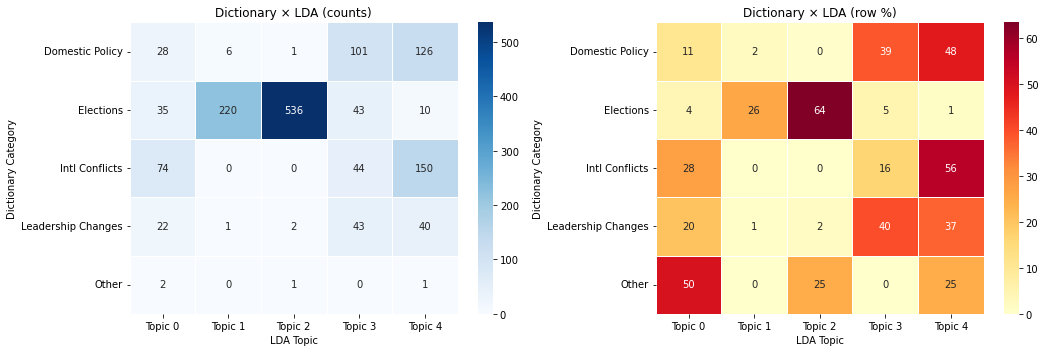

In [32]:
# Cross-tabulation heatmap
import matplotlib.pyplot as plt
import seaborn as sns

ct = pd.crosstab(df['event_type'], df['lda_topic'])
ct.columns = [f'Topic {i}' for i in ct.columns]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=.5)
axes[0].set_title('Dictionary × LDA (counts)')
axes[0].set_ylabel('Dictionary Category')
axes[0].set_xlabel('LDA Topic')

sns.heatmap(ct_pct, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1], linewidths=.5)
axes[1].set_title('Dictionary × LDA (row %)')
axes[1].set_ylabel('Dictionary Category')
axes[1].set_xlabel('LDA Topic')

plt.tight_layout()
plt.show()

### NMF

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

titles = df['title'].fillna('').str.lower()

tfidf = TfidfVectorizer(
    max_features=500,
    stop_words='english',
    min_df=3,
    max_df=0.7,
    ngram_range=(1, 2),
)
X_tfidf = tfidf.fit_transform(titles)

try:
    feature_names = tfidf.get_feature_names_out()
except AttributeError:
    feature_names = tfidf.get_feature_names()

nmf = NMF(n_components=5, random_state=42, max_iter=500)
doc_topics = nmf.fit_transform(X_tfidf)
df['nmf_topic'] = doc_topics.argmax(axis=1)

print("NMF Topics (top 10 terms each):")
print("=" * 60)
for i, topic in enumerate(nmf.components_):
    top_terms = [feature_names[j] for j in topic.argsort()[:-11:-1]]
    n = (df['nmf_topic'] == i).sum()
    print(f"\n  Topic {i} ({n} events):")
    print(f"    {', '.join(top_terms)}")

NMF Topics (top 10 terms each):

  Topic 0 (631 events):
    election winner, election, house election, house, winner, ca, 01 house, 02 house, 01, 02

  Topic 1 (226 events):
    primary, primary winner, democratic, republican, winner, senate, republican primary, governor, senate primary, democratic primary

  Topic 2 (223 events):
    31, march 31, march, trump, charged, 2026, charged march, tariff, odds, 31 2026

  Topic 3 (268 events):
    2027, trump, iran, nato, 2026, president, debt, china, ukraine, leader

  Topic 4 (138 events):
    russia, capture, russia capture, 30, june, russia enter, enter, june 30, 2026, ukraine


C:\Users\polin\anaconda3\lib\site-packages\sklearn\decomposition\_nmf.py:312: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(("The 'init' value, when 'init=None' and "


In [34]:
# Agreement
cat_codes = pd.Categorical(df['event_type']).codes
ari = adjusted_rand_score(cat_codes, df['nmf_topic'])
nmi = normalized_mutual_info_score(cat_codes, df['nmf_topic'])
print(f"ARI: {ari:.3f}")
print(f"NMI: {nmi:.3f}")

ARI: 0.476
NMI: 0.430


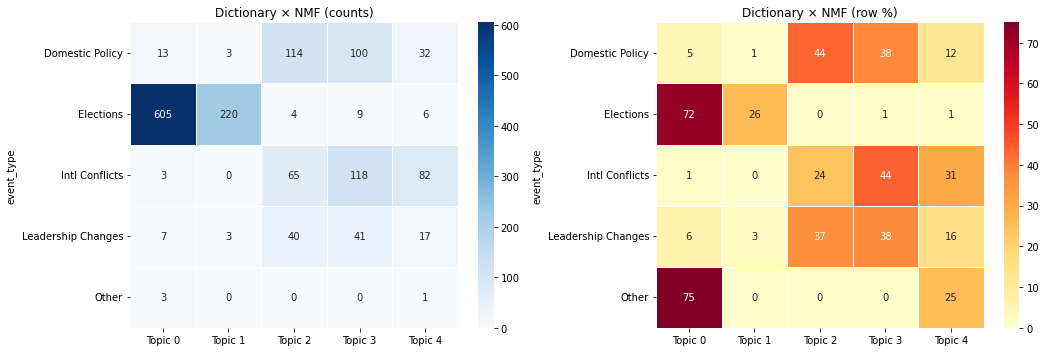

In [35]:
# Cross-tab heatmap
ct = pd.crosstab(df['event_type'], df['nmf_topic'])
ct.columns = [f'Topic {i}' for i in ct.columns]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=.5)
axes[0].set_title('Dictionary × NMF (counts)')
sns.heatmap(ct_pct, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1], linewidths=.5)
axes[1].set_title('Dictionary × NMF (row %)')
plt.tight_layout()
plt.show()